In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

import pmdarima as pm
import arch
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy import optimize

# 데이터 불러오기
original = pd.read_csv('c:\python\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])
print(original.head())

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

p_eriod = -52

def holt_winters(x, alpha, theta=None, exog=None, initial_level=None):
    """
    Holt-Winters Exponential Smoothing Algorithm with Exogenous Variables
    """
    """
    Holt-Winters Exponential Smoothing Algorithm with Exogenous Variables
    Parameters:
        x (array-like): Time series data
        alpha (float): Level smoothing coefficient (0 < alpha < 1)
        beta (float): Trend smoothing coefficient (0 < beta < 1)
        gamma (float): Seasonal smoothing coefficient (0 < gamma < 1)
        period (int): Seasonal period
        theta (array-like): Coefficients for exogenous variables
        exog (array-like): Exogenous variables (2D array, rows=time periods, cols=variables)
        seasonal (str): "additive" or "multiplicative"
    
    Returns:
        dict: Contains 'fitted', 'level', 'trend', 'seasonal', 'SSE'
    """
    n = len(x)
    
    # 초기화
    level = np.zeros(n+1)
    fitted = np.zeros(n+1)
    SSE = 0

    # 외생변수 영향 계산
    exog_effect = np.zeros(n)
    if exog is not None and theta is not None:
        exog_effect = np.dot(exog, theta)

    # === 초기값 자동 추정 ===
    level[0] = initial_level

    # Holt-Winters 지수 평활법 적용
    for t in range(n):
        
        # fitted는 level[t]에 해당 (시점 t에서의 예측값)
        fitted[t] = level[t]

        # 오차 계산
        error = x.iloc[t] - fitted[t]
        SSE += error**2

        # 다음 레벨 계산
        exog_term = exog_effect[t] if exog is not None else 0
        level[t + 1] = alpha * x.iloc[t] + (1 - alpha) * (level[t] + exog_term)
    
    fitted[n] = level[n]
    
    return {
        "fitted": fitted,
        "level": level,
        "SSE": SSE
    }

def objective_function_fixed_alpha(params, x, alpha, exog=None):
    
    # 외생변수 계수 (있는 경우)
    theta = None
    if exog is not None and len(params) > 2:
        theta = params[2:]
    
    # Holt-Winters 수행
    result = holt_winters(x, alpha, theta, exog)
    
    return result["SSE"]

def optimize_hw_parameters_fixed_alpha(x, alpha=0.1, exog=None, initial_params=None, initial_level=None):
    # 초기값 (beta, gamma)
    if initial_params is None:
        initial_params = [0.1, 0.3]
        if exog is not None:
            initial_params.extend([0.1] * exog.shape[1])

    # bounds 설정
    bounds = [(0.001, 0.999)] * 2  # beta, gamma
    if exog is not None:
        bounds.extend([(-1e9, 1e9)] * exog.shape[1])

    # 최적화
    result = optimize.minimize(
        objective_function_fixed_alpha,
        initial_params,
        args=(x, alpha, exog),
        method='L-BFGS-B',
        bounds=bounds
    )

    theta = result.x[2:] if exog is not None else None

    model = holt_winters(x, alpha, theta, exog, initial_level)

    return {
        "alpha": alpha,
        "theta": theta,
        "SSE": model["SSE"],
        "fitted": model["fitted"],
        "level": model["level"],
        "optimization_result": result,
    }



     HS10단위부호       수리일자 무역거래처국가코드     신고중량  과세가격미화금액    연도  월  주차   연도주차
0  8542391000 2017-01-01        SG   64.652     59061  2017  1  52  17_52
1  6109101000 2017-01-01        US    0.680        50  2017  1  52  17_52
2  8481801090 2017-01-01        US    9.100      2205  2017  1  52  17_52
3  7318159000 2017-01-02        BE  128.534      3210  2017  1   1  17_01
4  8479909090 2017-01-02        CN 3043.295    166420  2017  1   1  17_01


HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
21_40주차
📌 estimated initial_level: 8426863.24558
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 97611354070972.4844
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_39주차
📌 estimated initial_level: 7147691.96178
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 106985628866171.1562
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_38주차
📌 estimated initial_level: 6056150.92963
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 132543652234704.0000
======================= 여기부터 GARCH 모델링

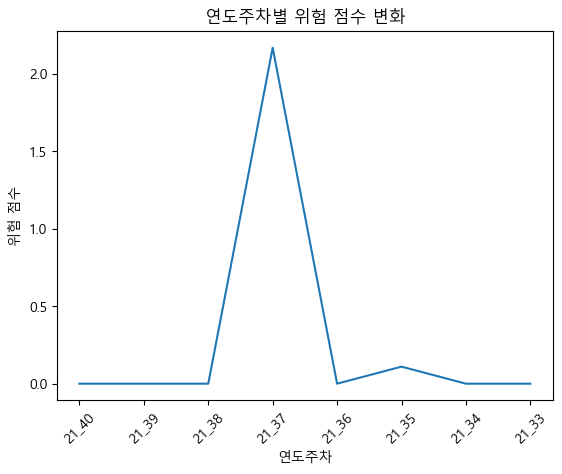

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
19_30주차
📌 estimated initial_level: 23928.18474
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 577566650.5141
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_29주차
📌 estimated initial_level: 23756.55832
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 521899660.4083
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_28주차
📌 estimated initial_level: 23843.67343
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 437861165.1103
======================= 여기부터 GARCH 모델링 =================================


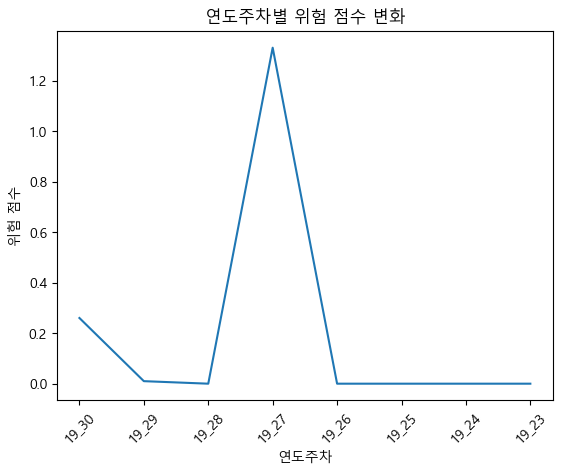

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
21_14주차
📌 estimated initial_level: 200854.53438
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 120672498176.6317
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_13주차
📌 estimated initial_level: 211574.90669
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 124392658181.1611
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_12주차
📌 estimated initial_level: 218500.2832
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 121225197739.0825
======================= 여기부터 GARCH 모델링 =================================
=

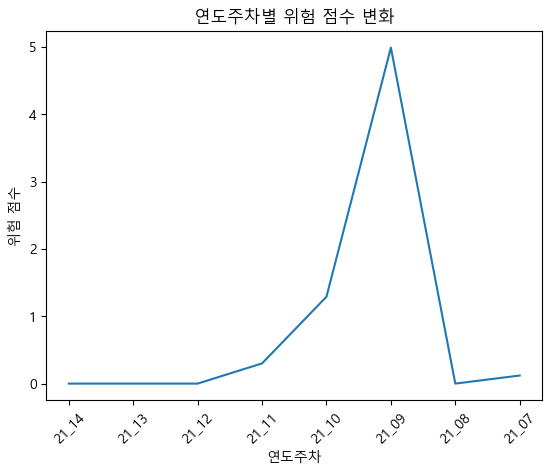

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
21_45주차
📌 estimated initial_level: 1922363.45617
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4384365257554.8208
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
📌 estimated initial_level: 1914642.56884
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4371961778526.6304
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
📌 estimated initial_level: 1827326.79485
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4469967355048.1924
======================= 여기부터 GARCH 모델링 ================

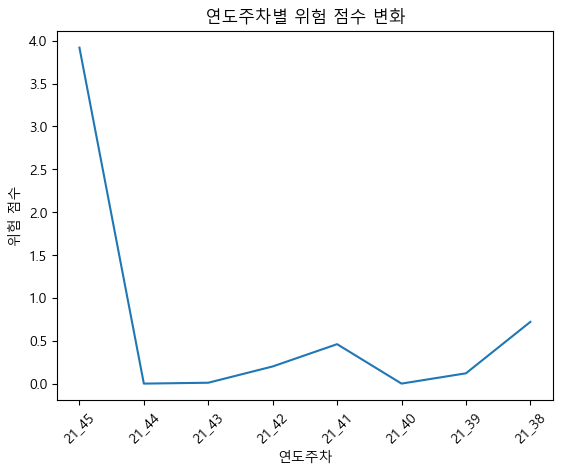

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
21_51주차
📌 estimated initial_level: 220013409.17139
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 111582959709301408.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_50주차
📌 estimated initial_level: 219957995.93707
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 109815973989141328.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_49주차
📌 estimated initial_level: 207516346.63354
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 114079758381336880.0000
==========

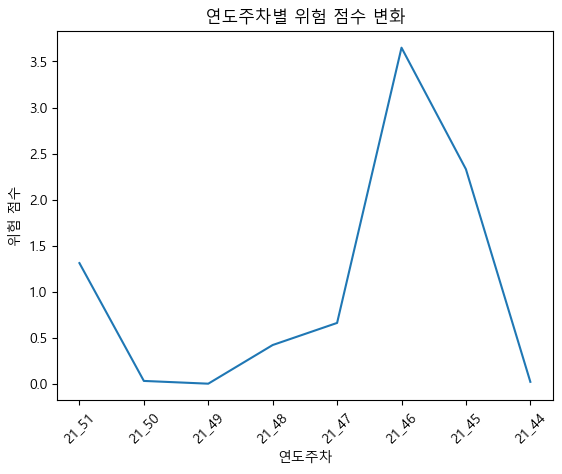

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
21_51주차
📌 estimated initial_level: 215827.15446
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 105727948769.0496
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_50주차
📌 estimated initial_level: 223457.19873
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 98657968739.0301
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_49주차
📌 estimated initial_level: 227146.38721
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 87624316151.3774
======================= 여기부터 GARCH 모델링 =================================
==

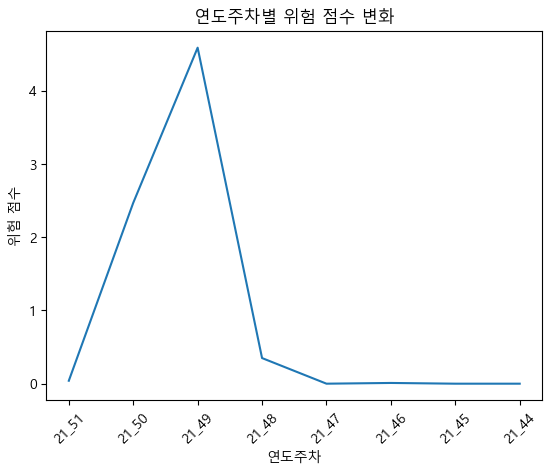

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
22_02주차
📌 estimated initial_level: 1157846.90888
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 7225083486589.7520
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_01주차
📌 estimated initial_level: 1127408.25017
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 7170608899838.0498
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_53주차
📌 estimated initial_level: 1200071.07468
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6464601300876.5977
======================= 여기부터 GARCH 모델링 ================

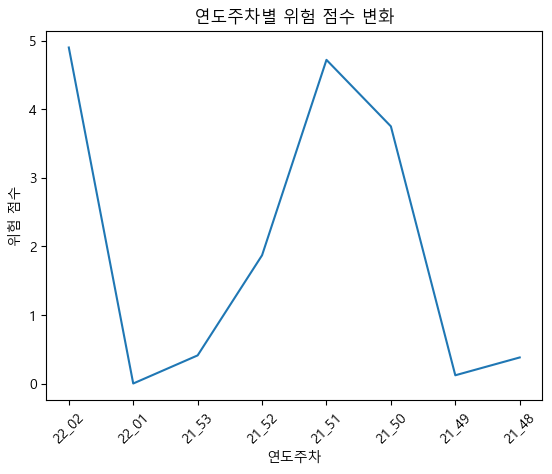

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 123619.97612
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 57754583120.7431
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_06주차
📌 estimated initial_level: 120750.0366
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 57131473845.6599
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_05주차
📌 estimated initial_level: 122373.58515
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 54946344297.5946
======================= 여기부터 GARCH 모델링 ===========================

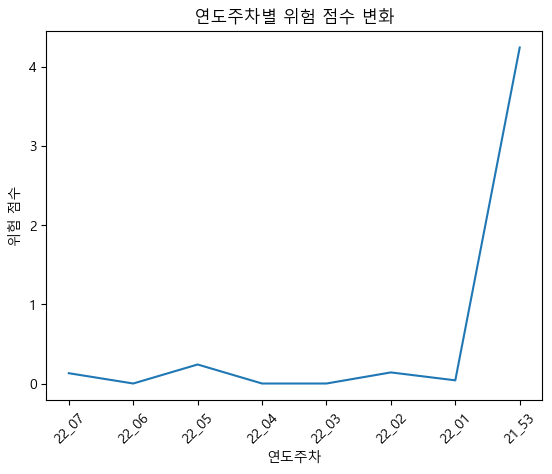

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
22_08주차
📌 estimated initial_level: 602247.80242
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 98879136812.2354
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_07주차
📌 estimated initial_level: 599872.11078
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 98402930326.6938
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_06주차
📌 estimated initial_level: 597674.28421
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 98155239719.1849
======================= 여기부터 GARCH 모델링 ==========================

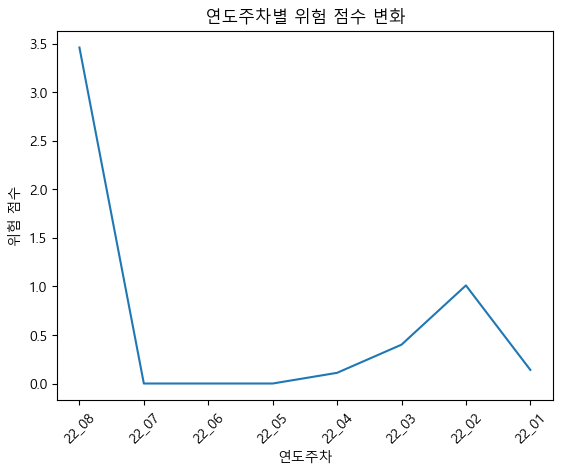

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 609586.26667
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2923255850751.0122
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_06주차
📌 estimated initial_level: 680461.625
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2864870746250.1465
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_05주차
📌 estimated initial_level: 670855.91667
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2700873442380.9707
======================= 여기부터 GARCH 모델링 =====================

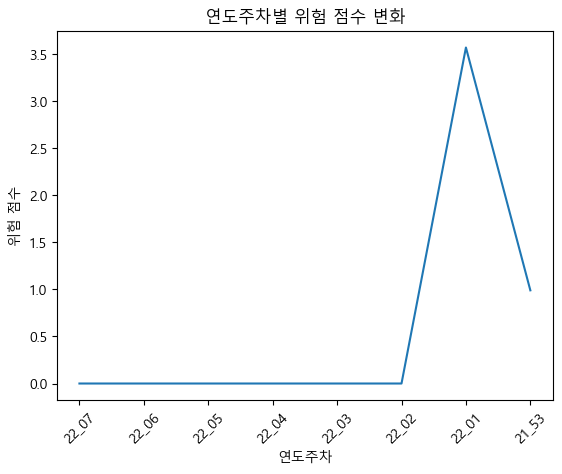

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 466327.38333
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 39129246225640.7656
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_06주차
📌 estimated initial_level: 972056.51667
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 43400997423249.6250
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_05주차
📌 estimated initial_level: 1540730.79131
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 43538177131777.2578
======================= 여기부터 GARCH 모델링 ===============

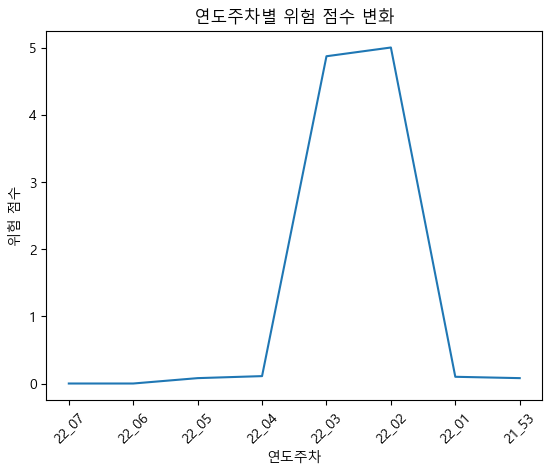

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 379015.06958
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 554181876950.1049
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_06주차
📌 estimated initial_level: 376430.74933
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 500258289578.6516
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_05주차
📌 estimated initial_level: 389384.06452
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 511618678455.8700
======================= 여기부터 GARCH 모델링 =================================


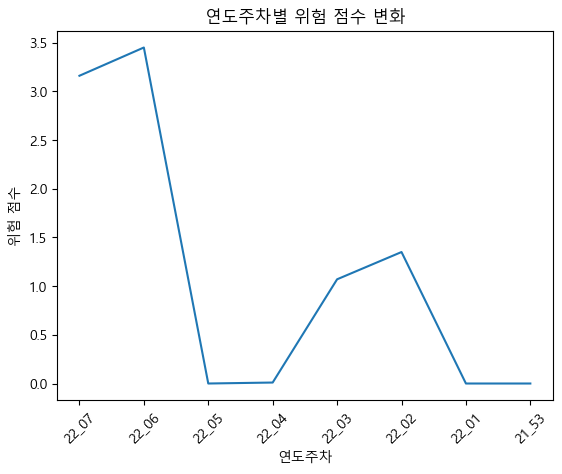

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 4701418.31133
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1131652402210647.7500
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_06주차
📌 estimated initial_level: 7022051.34333
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1103319839802372.5000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_05주차
📌 estimated initial_level: 10102479.93067
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1031916009323693.6250
======================= 여기부터 GARC

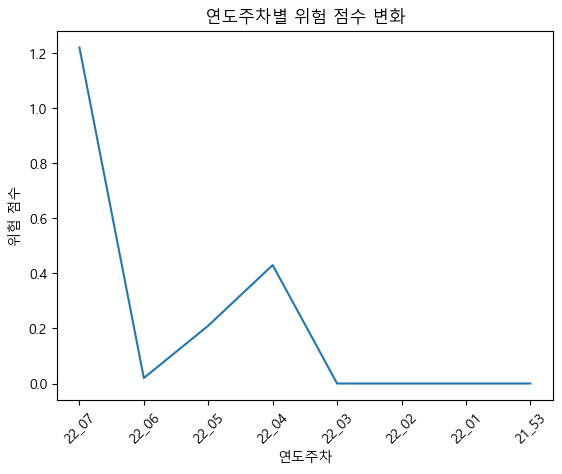

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 15227373.54253
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2301855956645765.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_06주차
📌 estimated initial_level: 19275445.56282
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2404370521691421.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_05주차
📌 estimated initial_level: 17174806.664
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2227860620632441.2500
======================= 여기부터 GARC

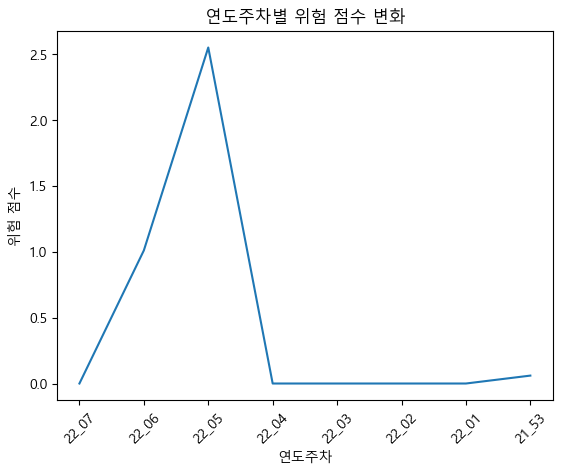

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
22_16주차
📌 estimated initial_level: 94114.04208
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 21175538459.3485
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_15주차
📌 estimated initial_level: 95810.76535
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 16587663587.8090
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_14주차
📌 estimated initial_level: 88604.18491
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 17557043067.0303
======================= 여기부터 GARCH 모델링 =================================
======

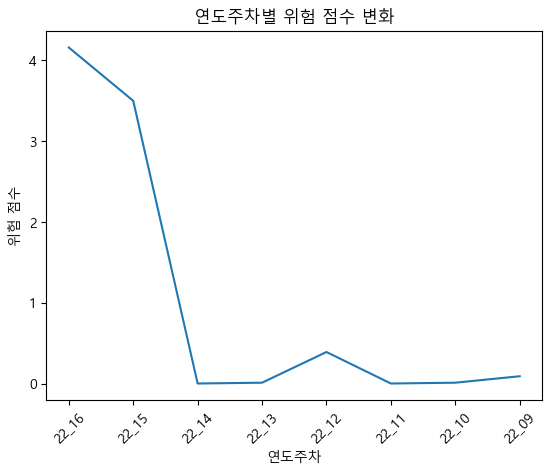

[np.float64(2.17), np.float64(1.33), np.float64(4.99), np.float64(3.92), np.float64(3.65), np.float64(4.59), np.float64(4.9), np.float64(4.24), np.float64(3.46), np.float64(3.57), np.float64(5.0), np.float64(3.45), np.float64(1.22), np.float64(2.55), np.float64(4.16)]
[54, 169, 82, 46, 45, 42, 36, 38, 30, 37, 36, 32, 31, 33, 22]


In [2]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]


z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)
      
   
    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 Exponential Smoothing 구하기 ====================
        ecdf = ECDF(df_price_4w.iloc[p_eriod-l:-l]['단가'])
        y=np.exp((ecdf(df_price_4w.iloc[-1-l]['단가'])*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop = True)
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
       
        model = ExponentialSmoothing(train, initialization_method="estimated")
        model_fit = model.fit(smoothing_level=0.2)
        estimated_level = round(model_fit.params["initial_level"], 5)
        print("📌 estimated initial_level:", estimated_level)
            
        print("최적화 (외생변수 없음):")
        result1 = optimize_hw_parameters_fixed_alpha(train, initial_level = estimated_level)
        print(f"최적 alpha: {result1['alpha']:.4f}")
        print(f"최소 SSE: {result1['SSE']:.4f}")

              
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = train - result1['fitted'][:-1]
        #est_residuals = model_fit.resid
        
        garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
               
        stand_quant = (test.iloc[0] - result1['fitted'][-1]) / garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y

    if(z[j]>1.85):
        o[j] = 1      
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model9(1)'] = o
collect.loc[15, 'Model9(1)'] = np.sum(o)
collect.loc[:14, 'Model9(2)'] = z
collect.loc[15, 'Model9(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[10]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[10]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[10]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
21_49주차
📌 estimated initial_level: 1808732.70523
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1529746794317.4741
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 1821338.75443
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1528340327893.9895
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 1826790.51701
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1522280791381.2881
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 1824505.14672
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1502787490240.6475
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 1822579.56967
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 14

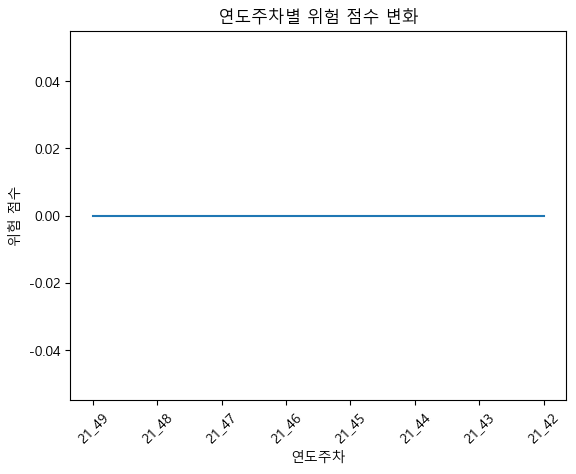

HS Code : 7326909000
21_49주차
📌 estimated initial_level: 9385756.24621
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 27308411138653.3672
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 9459770.20939
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 27519614159296.9102
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 9468725.82834
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 27725081475593.3516
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 9433936.71628
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 27572502483132.5625
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 9473037.96111
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE

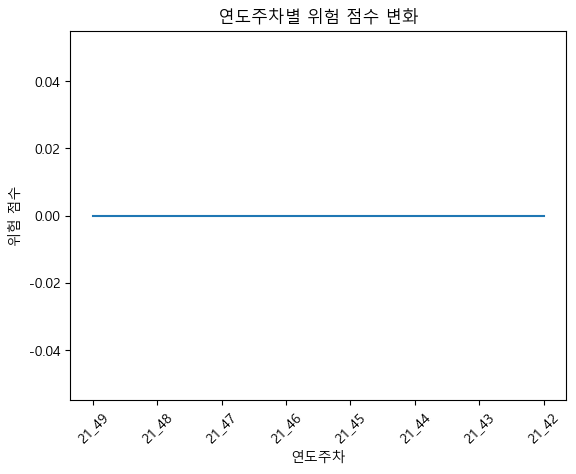

HS Code : 8708999000
21_49주차
📌 estimated initial_level: 1087618.83216
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 313860641940.0625
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 1092092.01242
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 313392306622.6978
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 1091584.31445
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 313367950516.9536
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 1086546.14033
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 314094499876.7267
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 1076512.49288
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 312114

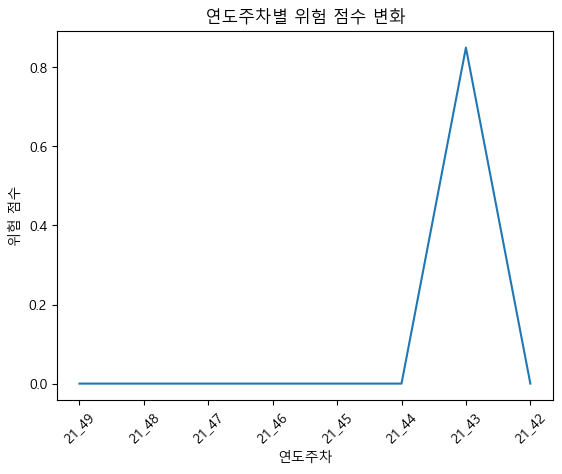

HS Code : 2106909099
21_49주차
📌 estimated initial_level: 1448731.42465
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1391125635642.5151
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 1439014.70863
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1378558594477.8335
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 1432970.49325
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1375527252056.5503
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 1426055.24066
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1341351272345.9224
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 1431355.21457
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 13

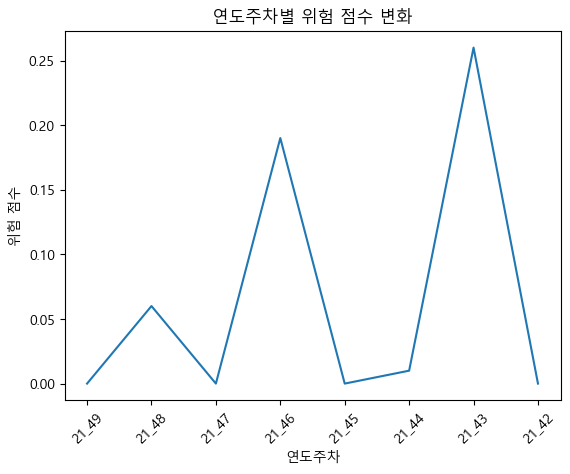

HS Code : 4911990000
21_49주차
📌 estimated initial_level: 34955.91495
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1397449080.0518
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 32783.81334
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1572885563.8191
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 33341.46725
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1493396501.1924
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 35687.82064
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1519944571.6069
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 37782.85154
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1588485041.6211
========

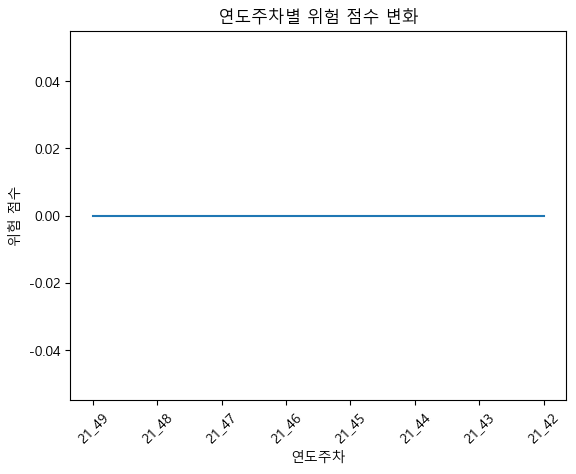

HS Code : 6403999000
21_49주차
📌 estimated initial_level: 184066.71522
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 20644702931.2793
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 187056.12699
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 20719869908.9650
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 189065.59985
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 20735046579.9854
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 185236.33573
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 21157111639.6705
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 177010.04813
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 22853161635.966

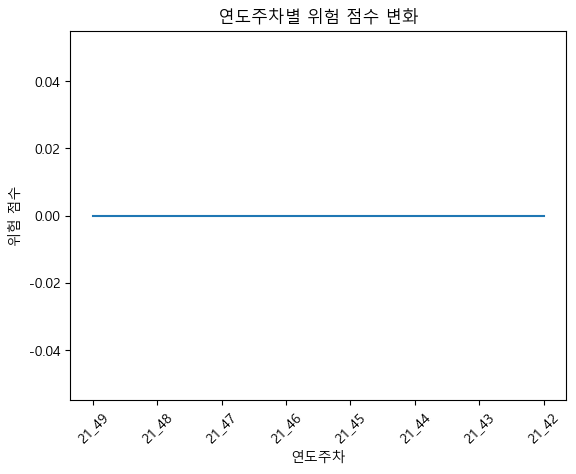

HS Code : 9031809099
21_49주차
📌 estimated initial_level: 140817.52466
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 26944220155.6211
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 149018.15444
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 28150389010.4728
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 153982.41702
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 28944928475.6746
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 158001.79165
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 29593796480.7143
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 158138.77726
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 29454448615.959

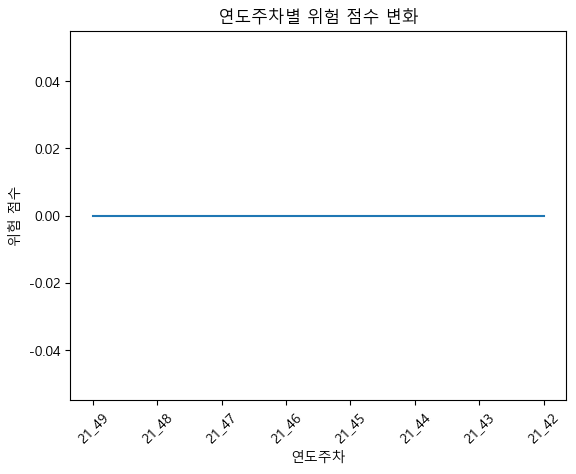

HS Code : 8542391000
21_49주차
📌 estimated initial_level: 59507.22353
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 744079501.9999
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 60178.22379
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 740934749.8887
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 60156.23328
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 741064776.8998
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 59829.1221
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 737379036.9036
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 59664.53655
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 719772337.6220
==============

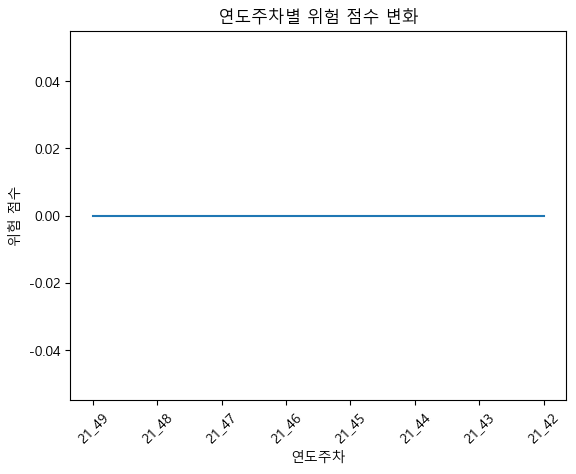

HS Code : 6109101000
21_49주차
📌 estimated initial_level: 369698.02643
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1519890437246.5122
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 336191.70854
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1591334370606.0461
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 309312.30906
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1645974353775.9619
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 280372.86816
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1699283422680.2178
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 267401.18152
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1720512

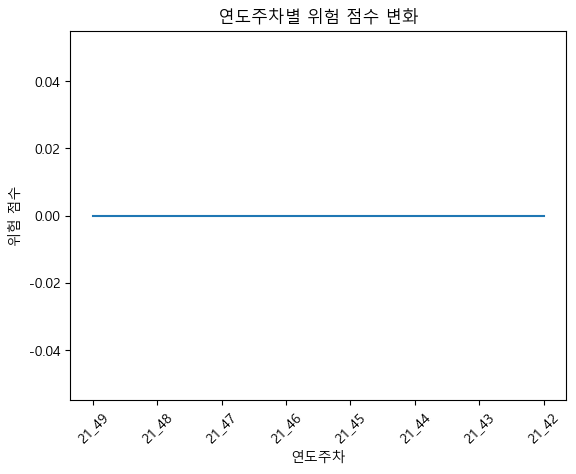

HS Code : 2934996000
21_49주차
📌 estimated initial_level: 17063.84698
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2909633032.7016
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 17127.38427
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2791433492.2868
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 17944.81701
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2442699570.0554
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 18833.39895
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2439202352.8227
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 20294.87005
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2501051383.6461
========

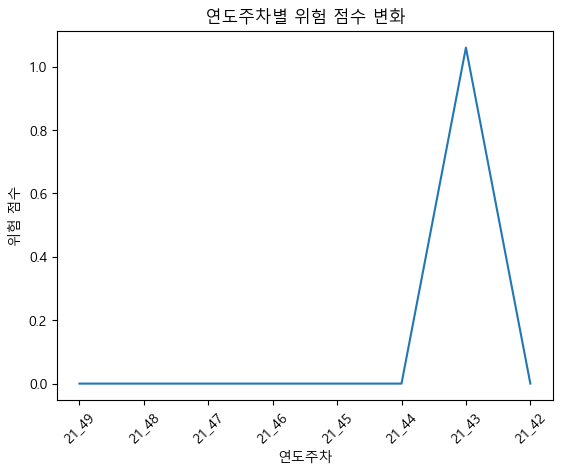

HS Code : 4016930000
21_49주차
📌 estimated initial_level: 98604.37533
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3931480128.4637
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 98540.62299
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3578081166.5703
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 99764.29586
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3634848638.3654
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 101488.30394
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3705660536.3362
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 101880.16447
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3726804353.7705
======

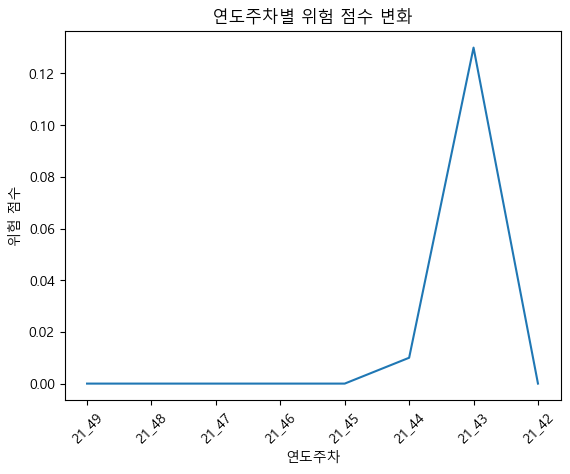

HS Code : 6110200000
21_49주차
📌 estimated initial_level: 315940.38341
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 825362133795.4575
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 312467.85008
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 823713291096.5817
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 303583.16036
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 820898261978.2629
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 302092.79255
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 818952375843.8774
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 301155.12757
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 81853657900

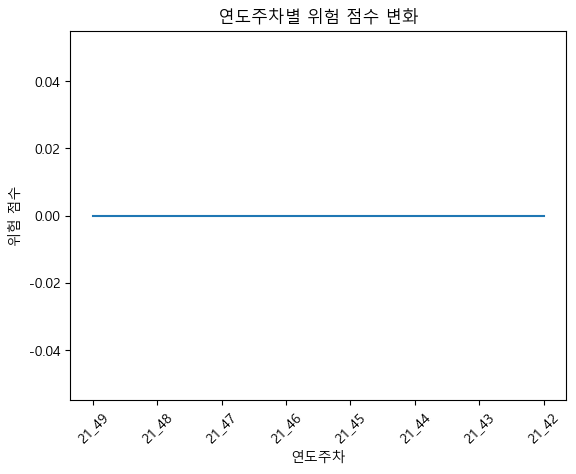

HS Code : 6211499000
21_49주차
📌 estimated initial_level: 24553.46665
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 483995333.9868
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 24767.68871
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 477837653.4519
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 24367.55285
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 480305215.3927
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 24409.48298
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 475791912.2625
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 23880.10373
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 455341660.9042
=============

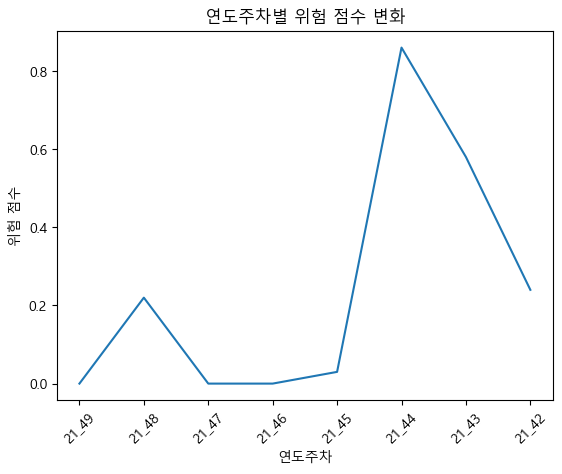

HS Code : 4202999000
21_49주차
📌 estimated initial_level: 61063.34636
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3995875625.1388
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 61794.34571
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4039238975.3953
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 62203.57139
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4062300705.4612
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 61608.82435
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4010907672.7511
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 60981.97035
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3907704403.3010
========

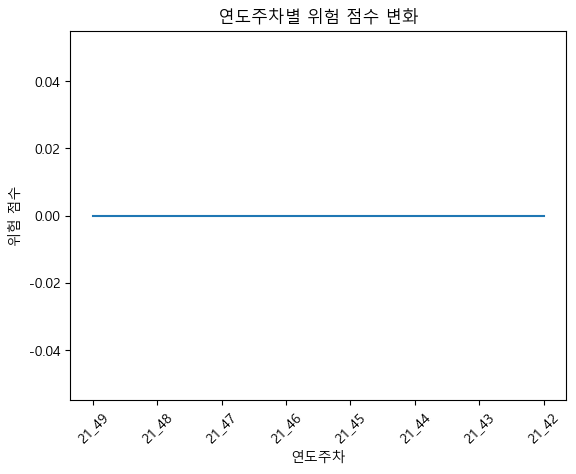

HS Code : 3304991000
21_49주차
📌 estimated initial_level: 789797.1387
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 480549659112.9290
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 803797.30374
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 488158568739.8588
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 811301.05425
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 490815493828.9913
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 819874.01071
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 478949649414.1713
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 801835.16737
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 473845611146

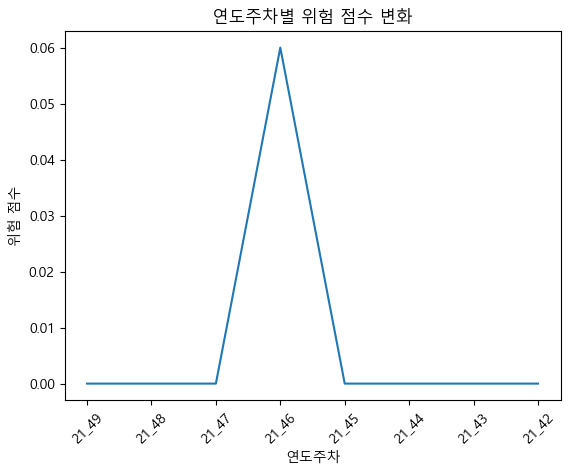

HS Code : 8544429090
21_49주차
📌 estimated initial_level: 99249.77934
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 13858784916.1121
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 99439.58221
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 13709995939.1159
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 98613.26291
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 13745582235.3342
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 97831.07298
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 13801884468.4931
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 98273.8135
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 12979945906.1881
====

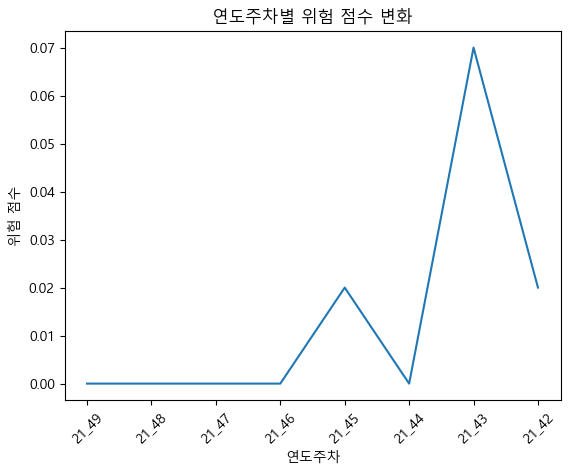

HS Code : 8481801090
21_49주차
📌 estimated initial_level: 733229.46443
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 352127345353.1458
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 731355.69832
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 351919403040.7697
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 728148.27215
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 353037742320.3548
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 727538.44425
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 352741706647.0772
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 722184.84363
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 35400720448

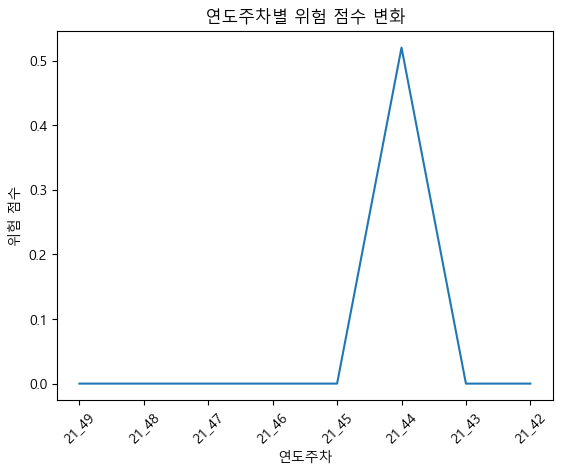

HS Code : 3304999000
21_49주차
📌 estimated initial_level: 67345.7584
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1704217011.9949
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 68583.20624
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1740100184.5267
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 68631.01427
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1721037169.5106
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 67898.33943
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1689601923.4675
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 68468.87332
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1672709873.9054
=========

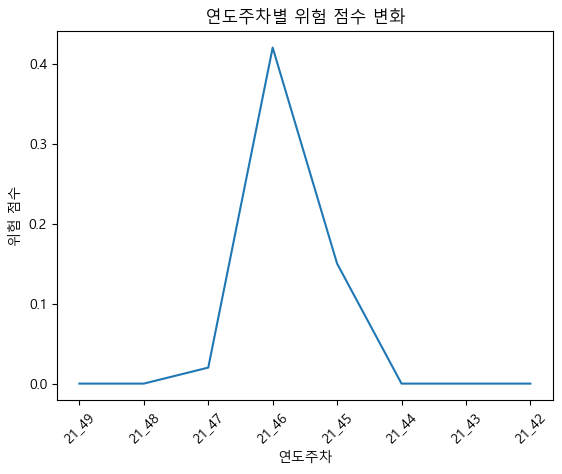

HS Code : 8543709090
21_49주차
📌 estimated initial_level: 116998.10677
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 65788850389.2648
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 116618.57812
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 65380989986.6616
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 115471.37157
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 65498348435.0168
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 113407.81733
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 65033045489.0718
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 112445.91406
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 64463552316.352

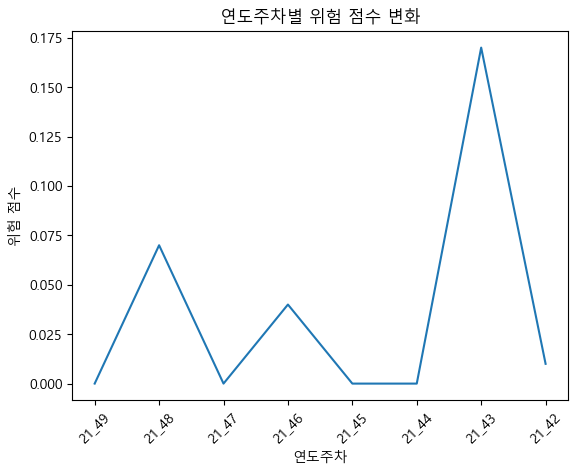

HS Code : 6404199000
21_49주차
📌 estimated initial_level: 492795.99068
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 195477373711.9830
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 495597.69847
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 193449673501.6037
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 495173.16496
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 193028758071.2836
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 487359.09315
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 195256908731.3082
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 484005.55317
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 19569216859

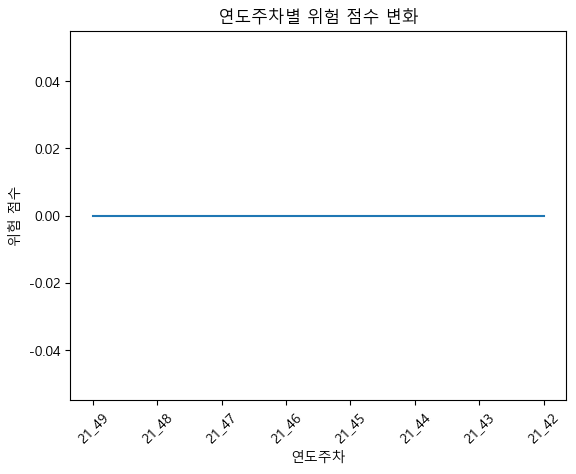

HS Code : 3004909900
21_49주차
📌 estimated initial_level: 996369.20256
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 633469428463.9841
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 991886.67505
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 629877508666.6677
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 999811.73821
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 606129339309.0922
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 1022381.54632
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 593256580145.7670
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 1059880.1107
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6158606352

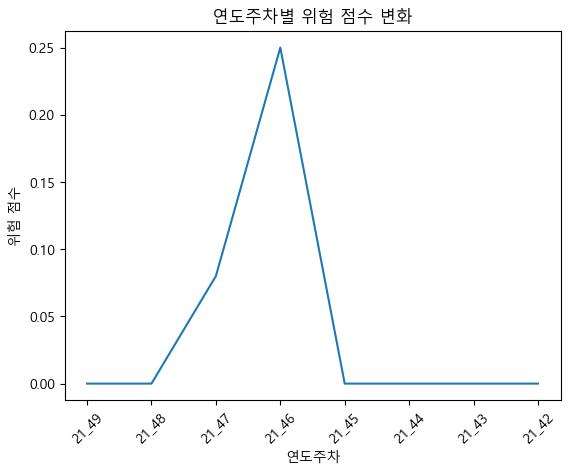

HS Code : 8542311000
21_49주차
📌 estimated initial_level: 63300.01315
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 686912619.2080
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 63098.80085
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 688274178.0836
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 63085.55665
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 688111294.1873
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 63219.70224
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 684089320.7322
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 63515.18282
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 672841604.0755
=============

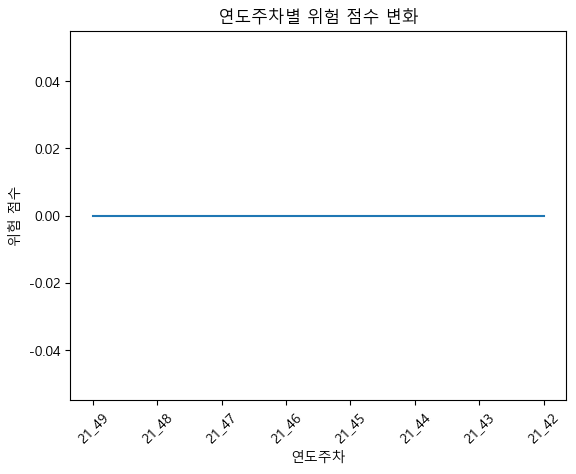

HS Code : 4901999000
21_49주차
📌 estimated initial_level: 146792.24691
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 11792940550.9793
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 141629.57669
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 11288762502.1882
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 135805.28885
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 11033755935.3397
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 130242.24879
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 10722051552.3319
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 125457.12673
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 10305140045.279

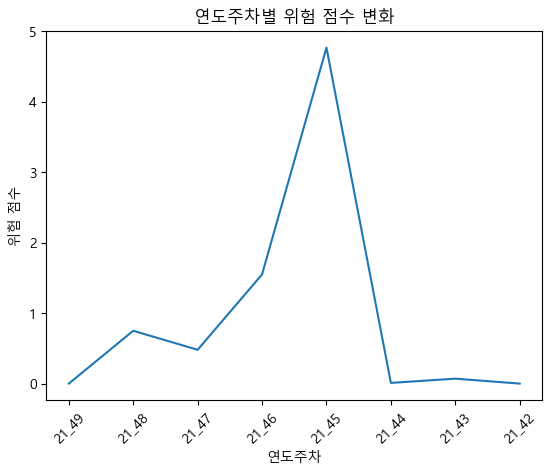

HS Code : 8473309090
21_49주차
📌 estimated initial_level: 94548.2103
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 7078598969.4246
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 94792.476
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 7025218055.9935
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 95101.68028
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 7002776346.3136
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 95127.05656
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6872832082.4487
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 93087.19598
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6700939740.9379
===========

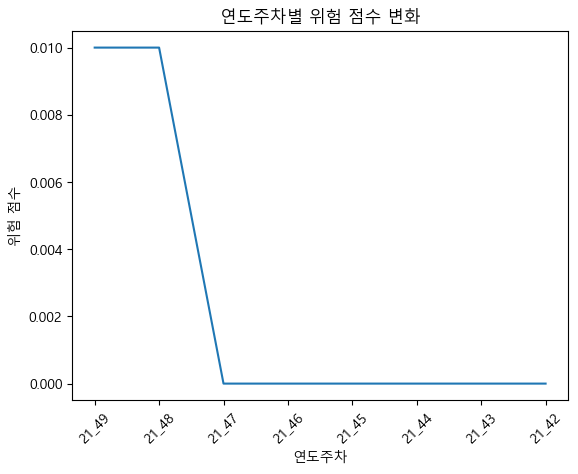

HS Code : 6307909000
21_49주차
📌 estimated initial_level: 812681.04536
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 517616080448.8578
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 835991.14186
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 548287430281.9792
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 860667.91808
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 578704304397.2979
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 871514.08742
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 590248043428.5316
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 874405.37027
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 59166562453

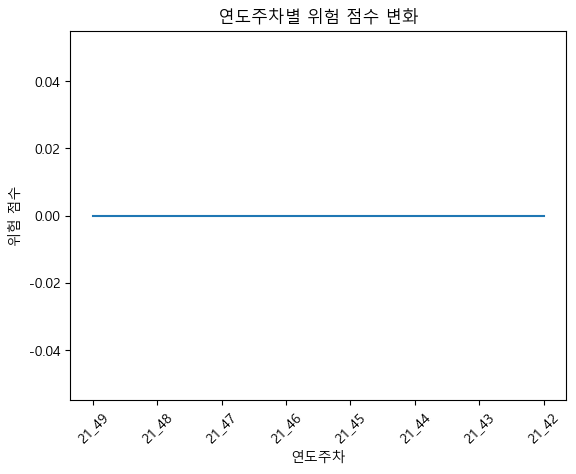

HS Code : 4202211090
21_49주차
📌 estimated initial_level: 50841.36083
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2113382062.7118
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 51056.42387
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2105303283.4175
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 51136.99653
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2090134482.3163
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 51055.42142
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2053748433.6868
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 50757.70549
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1988367907.2557
========

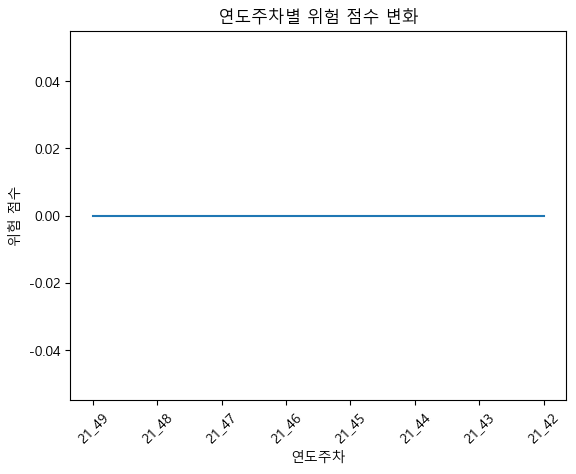

HS Code : 8536509090
21_49주차
📌 estimated initial_level: 60599.33608
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2260959579.3358
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 60690.17569
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2259517970.9922
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 60999.72734
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2240229448.1059
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 61341.86836
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2218936382.9440
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 61675.45247
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2146344802.0766
========

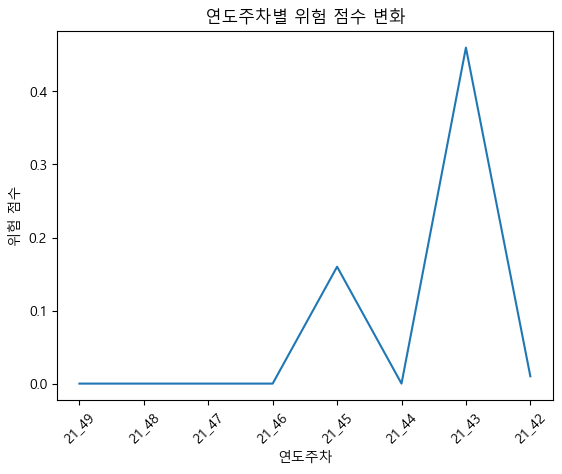

HS Code : 8538909000
21_49주차
📌 estimated initial_level: 198020.67229
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6257667193.0839
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 197757.77159
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6188752226.4453
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 196759.12833
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6254185804.3632
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 194791.35436
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6283971049.2562
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 195358.06075
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6177668662.0283
===

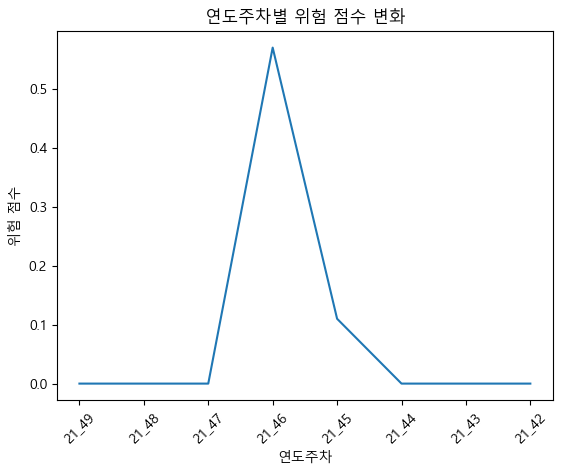

HS Code : 8479909090
21_49주차
📌 estimated initial_level: 119695.77939
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 58239769215.3099
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 115218.19433
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 58416011232.8651
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 109592.70619
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 59343141065.1545
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 105996.1696
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 60076834808.7930
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 105739.55961
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 60017125514.3719

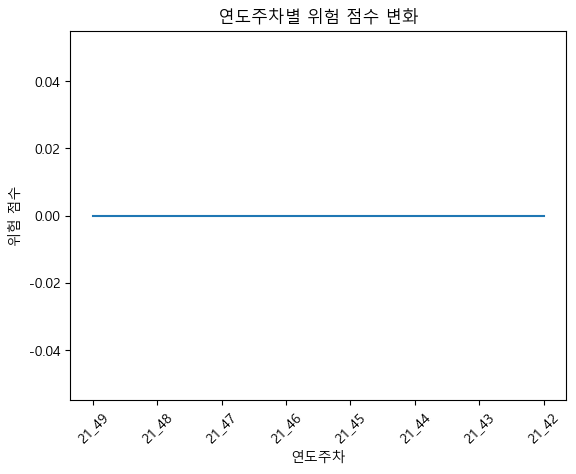

HS Code : 8504409099
21_49주차
📌 estimated initial_level: 195502.6263
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 19766713811.7066
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 197521.62861
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 19906130242.7025
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 199535.30745
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 20128194724.1622
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 204449.59145
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 20938992949.5045
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 203565.3326
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 20639472126.0953


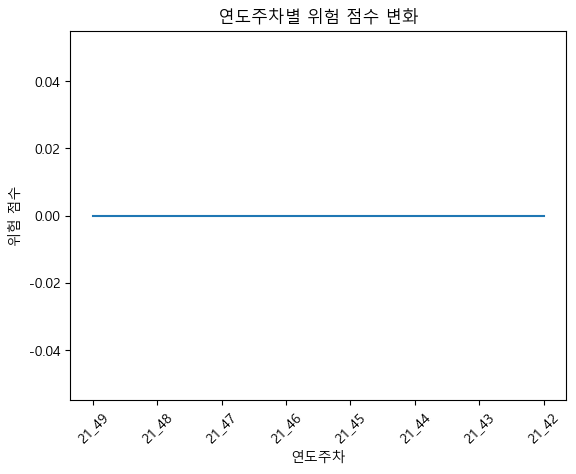

HS Code : 6110909000
21_49주차
📌 estimated initial_level: 7765.95097
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 237027809.1445
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 7993.13317
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 238011331.0238
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 8158.62165
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 238971899.7065
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 8368.88637
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 240421194.2775
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 8650.68294
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 243568472.3008
==================

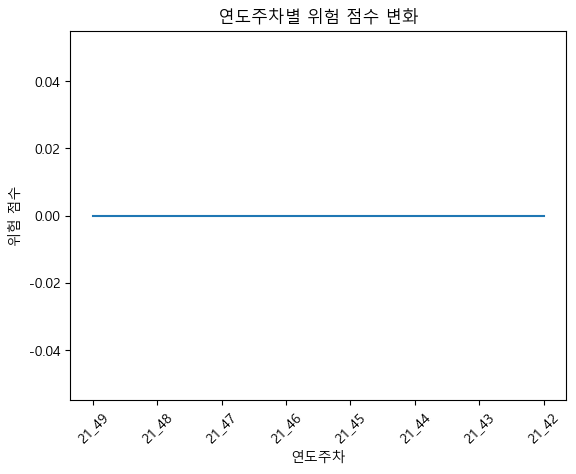

HS Code : 3923100000
21_49주차
📌 estimated initial_level: 2701656.53851
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 621306861289.6462
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 2732863.04761
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 612873102896.5190
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 2745676.14241
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 600165938761.3563
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 2753132.50057
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 553034874783.9255
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 2772111.15374
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 561269

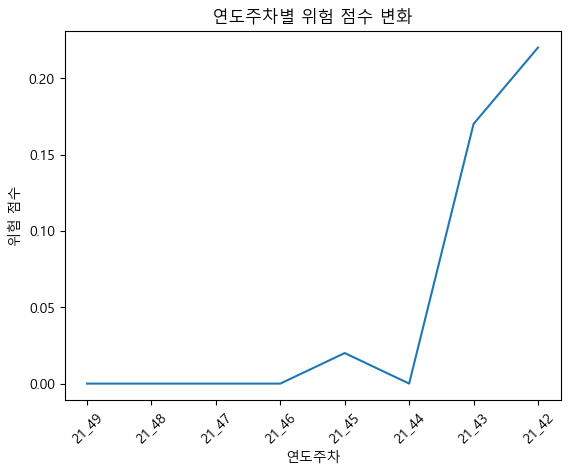

HS Code : 8544422090
21_49주차
📌 estimated initial_level: 579740.8842
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 106821907533.5743
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 585947.05932
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 106668738477.5962
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 591006.8981
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 106655345037.1981
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 593679.55305
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 106627097728.9027
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 596442.07301
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 106326984880.

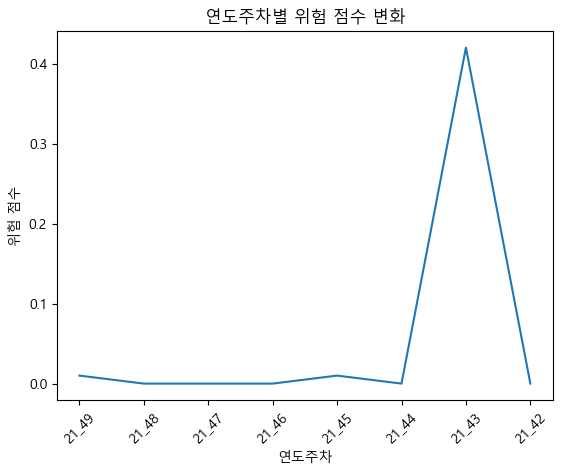

HS Code : 8537109000
21_49주차
📌 estimated initial_level: 72428.54426
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1333269934.2781
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 72174.4066
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1289950353.6992
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 74920.29164
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1460083327.0908
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 78569.17843
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1848539315.3473
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 80775.07551
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2071455578.2499
=========

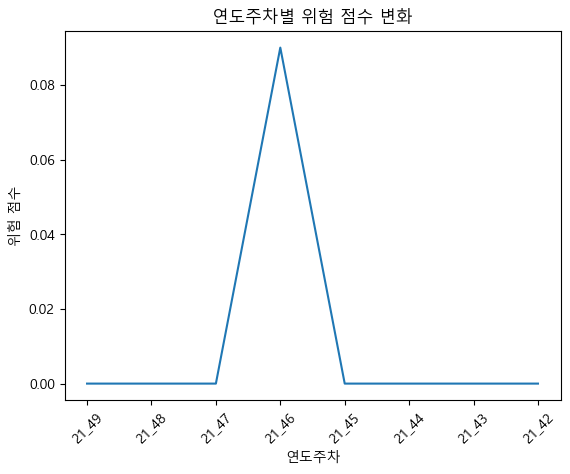

HS Code : 8536699000
21_49주차
📌 estimated initial_level: 134557.75535
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 10962591536.7785
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
📌 estimated initial_level: 133943.34823
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 10959477283.1909
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
📌 estimated initial_level: 132166.6946
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 10744798860.6297
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
📌 estimated initial_level: 130340.75477
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 10758315808.1579
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
📌 estimated initial_level: 129776.23701
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 10763289377.1497

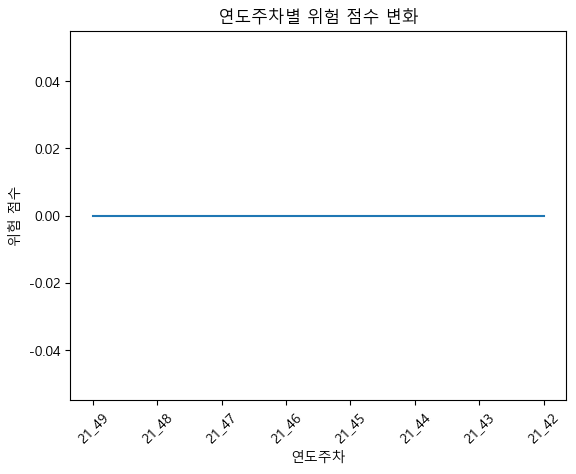

HS Code : 3102109000
21_14주차
📌 estimated initial_level: 6744852.72644
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 170982261644911.4375
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_13주차
📌 estimated initial_level: 6463554.59068
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 174072482703938.3750
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_12주차
📌 estimated initial_level: 7777835.8824
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 180679287721481.5625
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_11주차
📌 estimated initial_level: 8015536.11993
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 182629871853724.4062
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_10주차
📌 estimated initial_level: 9095382.1687
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 S

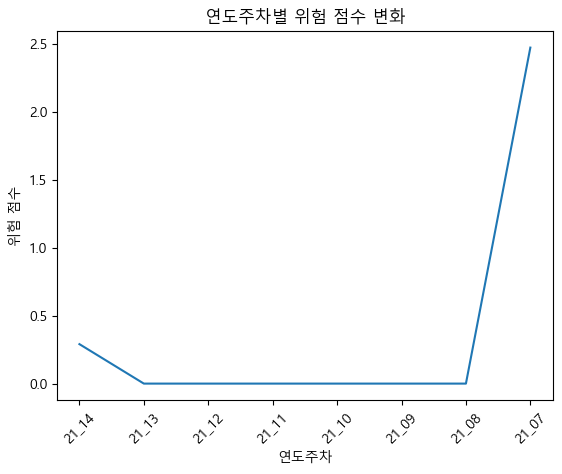

HS Code : 3707901010
19_04주차
📌 estimated initial_level: 20941.45232
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 321437110.0680
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_03주차
📌 estimated initial_level: 19926.40288
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 357990671.6498
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_02주차
📌 estimated initial_level: 19641.63215
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 363404707.4313
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_01주차
📌 estimated initial_level: 20248.72921
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 361902176.6555
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
18_52주차
📌 estimated initial_level: 20632.33384
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 341154413.5904
=============

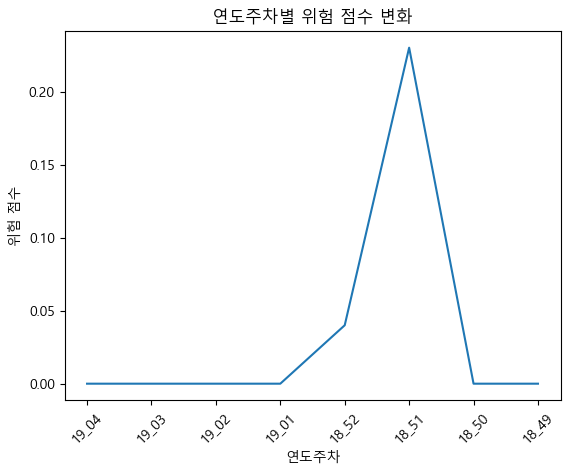

HS Code : 4407191000
20_41주차
📌 estimated initial_level: 171498.912
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 71261387705.1055
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
20_40주차
📌 estimated initial_level: 180736.56896
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 72273658220.2957
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
20_39주차
📌 estimated initial_level: 188237.60533
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 73296362629.0594
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
20_38주차
📌 estimated initial_level: 195218.58467
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 74320096466.9293
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
20_37주차
📌 estimated initial_level: 204493.7229
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 77000258960.4106
=

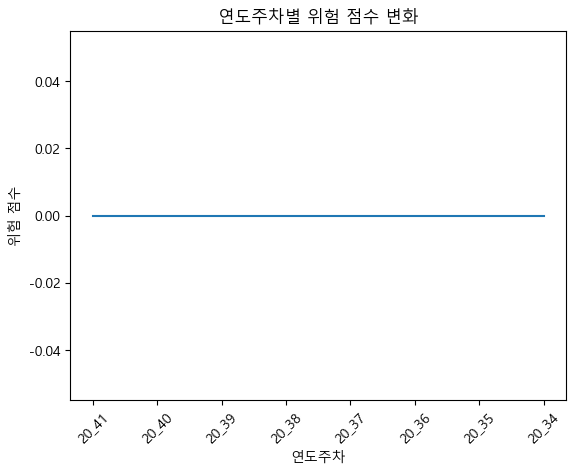

HS Code : 8111000000
21_19주차
📌 estimated initial_level: 1848526.72099
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6547518339847.6855
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_18주차
📌 estimated initial_level: 1999017.03143
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 7426542236402.1484
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_17주차
📌 estimated initial_level: 2009672.0898
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 7405844450106.2100
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_16주차
📌 estimated initial_level: 1967131.68871
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 6952427346384.4385
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_15주차
📌 estimated initial_level: 1931441.16456
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 646

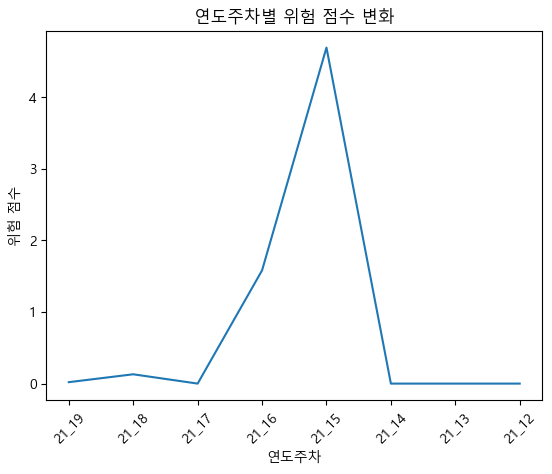

HS Code : 2701129010
21_25주차
📌 estimated initial_level: 109331872.82
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 89484837071775536.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_24주차
📌 estimated initial_level: 92893951.1905
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 99210819980768992.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_23주차
📌 estimated initial_level: 80118321.54458
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 107222205876371952.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_22주차
📌 estimated initial_level: 73923534.26358
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 106619437018880016.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_21주차
📌 estimated initial_level: 94042419.93817
최적화 (외생변수 없음):
최적 alph

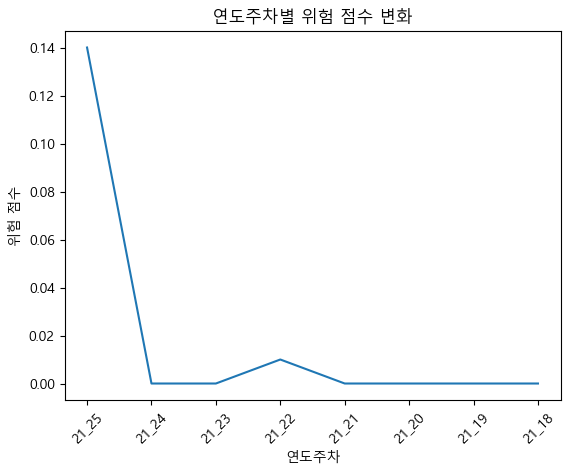

HS Code : 2804701000
21_25주차
📌 estimated initial_level: 197426.08753
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 78966375237.6885
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_24주차
📌 estimated initial_level: 189200.5442
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 75688679305.3513
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_23주차
📌 estimated initial_level: 188815.77083
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 73116269461.4869
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_22주차
📌 estimated initial_level: 193796.33333
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 73591363730.4173
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_21주차
📌 estimated initial_level: 186644.33333
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 74644157760.1337

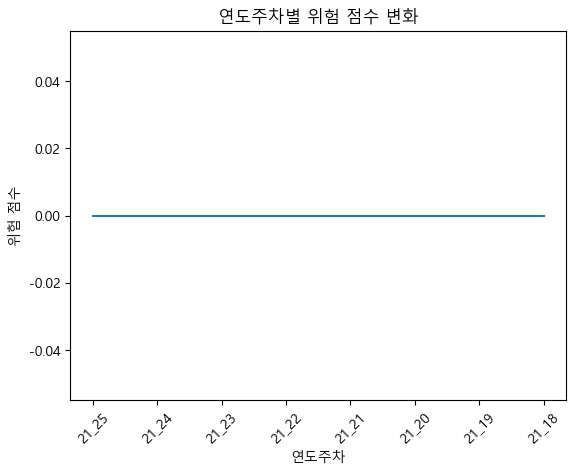

HS Code : 1511901000
21_29주차
📌 estimated initial_level: 920784.34083
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 5824469938565.8779
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_28주차
📌 estimated initial_level: 989020.49514
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4941831597254.2178
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_27주차
📌 estimated initial_level: 1038152.61333
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4986786958563.2861
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_26주차
📌 estimated initial_level: 1052518.08092
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4992359645334.4531
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_25주차
📌 estimated initial_level: 1011173.29717
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4992

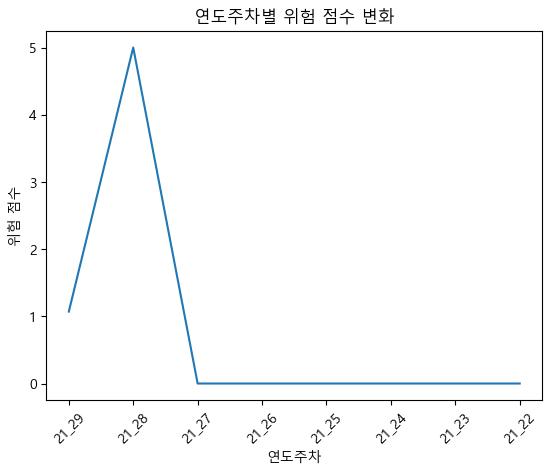

HS Code : 305531000
21_34주차
📌 estimated initial_level: 159107.55479
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 25541553605.0754
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_33주차
📌 estimated initial_level: 160927.45375
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 25352138368.8314
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_32주차
📌 estimated initial_level: 162361.70985
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 25019808462.3797
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_31주차
📌 estimated initial_level: 163119.41869
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 25014312873.2826
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_30주차
📌 estimated initial_level: 168471.22884
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 25878151742.8487

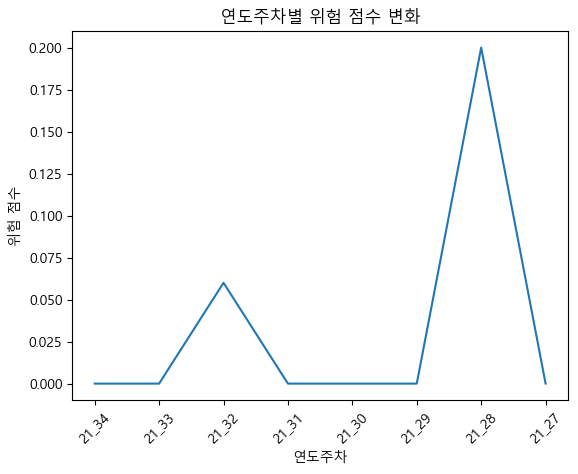

HS Code : 302140000
21_35주차
📌 estimated initial_level: 489161.04597
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 68248979028.1587
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_34주차
📌 estimated initial_level: 476879.90954
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 75240543143.2227
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_33주차
📌 estimated initial_level: 469987.5645
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 77992099739.0490
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_32주차
📌 estimated initial_level: 463920.97201
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 80388566821.4761
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_31주차
📌 estimated initial_level: 459939.32727
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 79562979817.9534


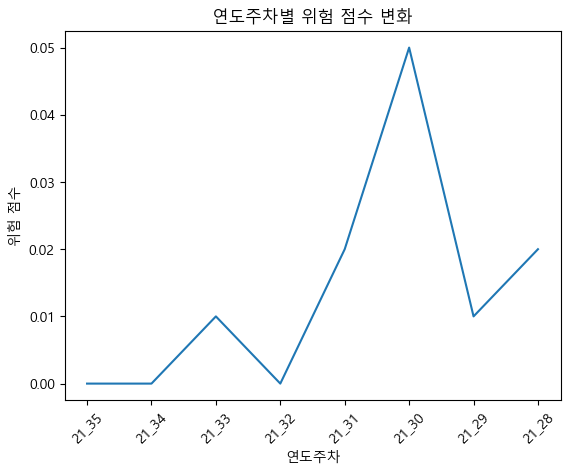

HS Code : 1003901000
21_34주차
📌 estimated initial_level: 646781.05076
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3532886850751.2402
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_33주차
📌 estimated initial_level: 517084.06932
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3957213205509.3911
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_32주차
📌 estimated initial_level: 456576.51667
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3970841291153.4360
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_31주차
📌 estimated initial_level: 467545.55
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3896852517213.6460
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_30주차
📌 estimated initial_level: 514882.45
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3742244551436

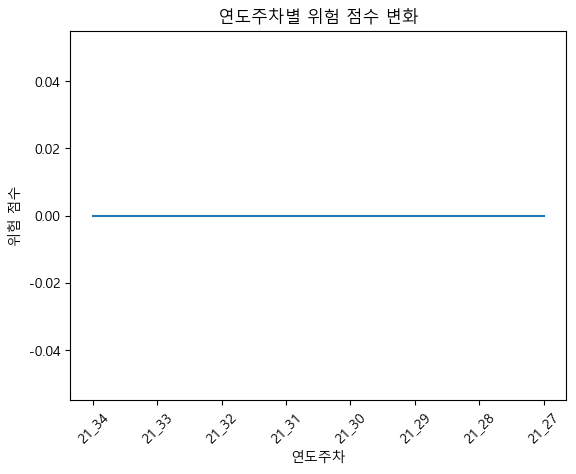

HS Code : 1003902000
21_34주차
📌 estimated initial_level: 113914.13333
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 32984980406847.2188
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_33주차
📌 estimated initial_level: 133093.46667
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 32893660934956.8477
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_32주차
📌 estimated initial_level: 132957.66667
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 32877260446053.4531
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_31주차
📌 estimated initial_level: 143522.16667
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 32855928540598.6523
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_30주차
📌 estimated initial_level: 139706.05
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 328447

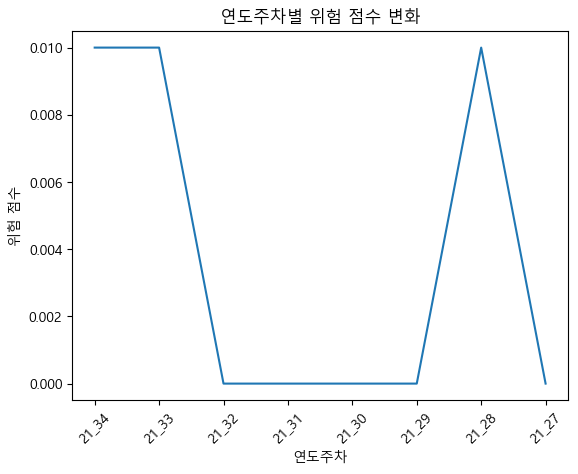

HS Code : 1104230000
21_34주차
📌 estimated initial_level: 400509.17578
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1187892558091.9529
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_33주차
📌 estimated initial_level: 360725.23216
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1205930157239.8164
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_32주차
📌 estimated initial_level: 326690.47087
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1214016203024.6323
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_31주차
📌 estimated initial_level: 334165.505
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1175287367844.7141
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_30주차
📌 estimated initial_level: 339206.63703
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 117033230

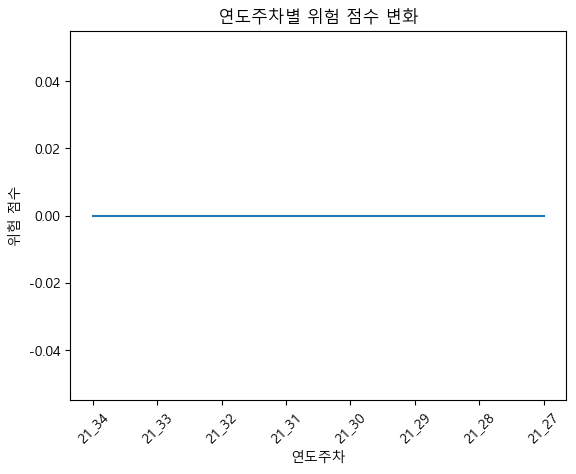

HS Code : 2710121000
21_34주차
📌 estimated initial_level: 5675399.92667
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 777563253471728.3750
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_33주차
📌 estimated initial_level: 3691761.45333
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 829938085657969.1250
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_32주차
📌 estimated initial_level: 6126643.47962
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 763131939719256.3750
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_31주차
📌 estimated initial_level: 2030232.47333
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 855351684149135.7500
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_30주차
📌 estimated initial_level: 5358248.84879
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소

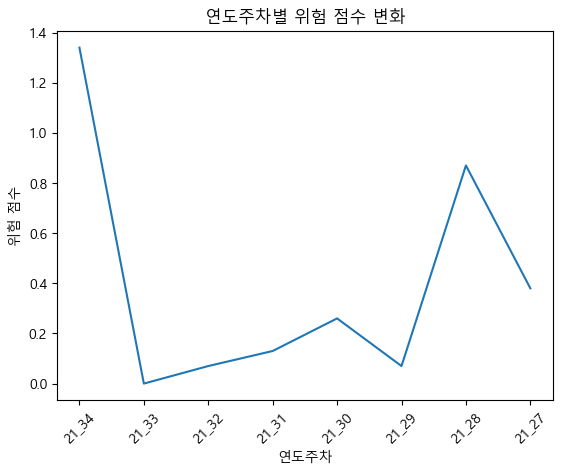

HS Code : 3104200000
21_34주차
📌 estimated initial_level: 7625464.78193
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2306539253956553.5000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_33주차
📌 estimated initial_level: 8273831.98573
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2258203399106796.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_32주차
📌 estimated initial_level: 9410688.79072
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2243045237301897.7500
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_31주차
📌 estimated initial_level: 12252861.40938
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2283786301953898.0000
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_30주차
📌 estimated initial_level: 14611316.42683
최적화 (외생변수 없음):
최적 alpha: 0.1

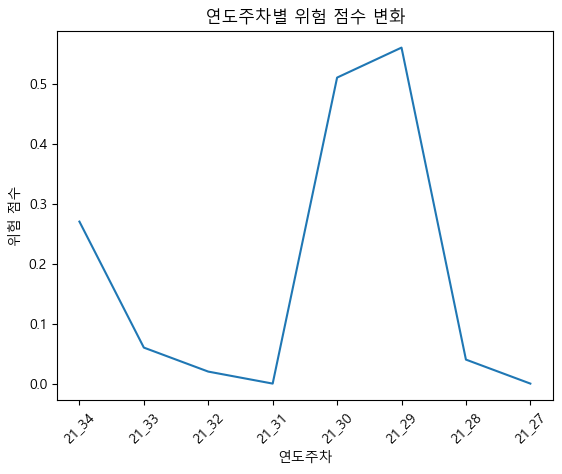

HS Code : 2905172000
21_43주차
📌 estimated initial_level: 86833.26828
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 15856488289.5095
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
📌 estimated initial_level: 80234.09806
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 16343365003.7978
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_41주차
📌 estimated initial_level: 73943.02566
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 17477694511.3876
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_40주차
📌 estimated initial_level: 65010.25761
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 19676105756.5888
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_39주차
📌 estimated initial_level: 57746.40556
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 20890580762.2123
===

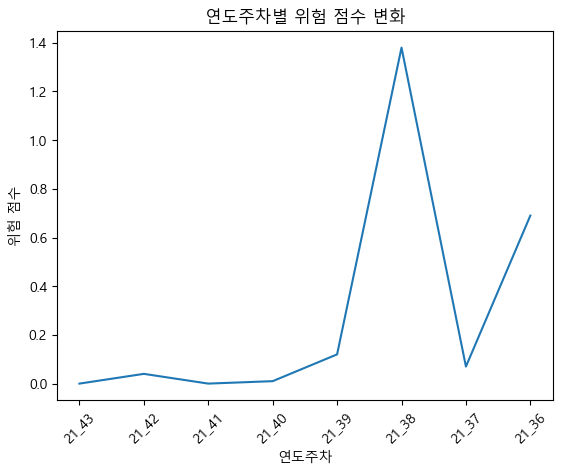

[0, 0, np.float64(0.85), np.float64(0.26), 0, 0, 0, 0, 0, np.float64(1.06), np.float64(0.13), 0, np.float64(0.86), 0, np.float64(0.06), np.float64(0.07), np.float64(0.52), np.float64(0.42), np.float64(0.17), 0, np.float64(0.25), 0, np.float64(4.77), np.float64(0.01), 0, 0, np.float64(0.46), np.float64(0.57), 0, 0, 0, np.float64(0.22), np.float64(0.42), np.float64(0.09), 0, np.float64(2.47), np.float64(0.23), 0, np.float64(4.69), np.float64(0.14), 0, np.float64(5.0), np.float64(0.2), np.float64(0.05), 0, np.float64(0.01), 0, np.float64(1.34), np.float64(0.56), np.float64(1.38)]
[0, 0, 48, 48, 0, 0, 0, 0, 0, 48, 48, 0, 47, 0, 45, 48, 47, 45, 48, 0, 45, 0, 46, 42, 0, 0, 48, 45, 0, 0, 0, 49, 48, 45, 0, 84, 197, 0, 76, 66, 0, 63, 63, 61, 0, 57, 0, 57, 62, 53]
DataFrame 길이: 15
리스트 k 길이: 50


In [3]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
     
    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 Exponential Smoothing 구하기 ====================
        ecdf = ECDF(df_price_4w.iloc[p_eriod-l:-l]['단가'])
        y=np.exp((ecdf(df_price_4w.iloc[-1-l]['단가'])*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop = True)
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
       
        model = ExponentialSmoothing(train, initialization_method="estimated")
        model_fit = model.fit(smoothing_level=0.2)
        estimated_level = round(model_fit.params["initial_level"], 5)
        print("📌 estimated initial_level:", estimated_level)
            
        print("최적화 (외생변수 없음):")
        result1 = optimize_hw_parameters_fixed_alpha(train, initial_level = estimated_level)
        print(f"최적 alpha: {result1['alpha']:.4f}")
        print(f"최소 SSE: {result1['SSE']:.4f}")

              
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = train - result1['fitted'][:-1]
        #est_residuals = model_fit.resid
        
        garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
               
        stand_quant = (test.iloc[0] - result1['fitted'][-1]) / garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y

    if(z[j]<1.85):
        o[j] = 1      
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)

print("DataFrame 길이:", len(collect['Model0(1)'].iloc[:-1]))
print("리스트 k 길이:", len(k))

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model9(1)'] = o
collect.loc[50, 'Model9(1)'] = np.sum(o)
collect.loc[:49, 'Model9(2)'] = z
collect.loc[50, 'Model9(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[10]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[10]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[10]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)